
# 🧠 DeepStock AI: LSTM-based Stock Price Prediction

This notebook builds and trains a **Deep Learning LSTM model** using TensorFlow/Keras to predict future stock prices.  
It uses the dataset `indexFinal_Clean.csv` and includes visualization of training performance and predicted results.

**Developed by:** Rayhan Kabir Dodi  
**Project:** Machine Learning & Artificial Intelligence  
**Model:** DeepStock AI (LSTM)


In [ ]:

# --- Importing Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score
import math


In [ ]:

# --- Load Dataset ---
file_path = "/content/indexFinal_Clean.csv"  # Ensure this file is in the same directory
data = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")
print("Shape:", data.shape)
print("\nColumns:", data.columns.tolist())
data.head()


Dataset Loaded Successfully!
Shape: (104224, 12)

Columns: ['Index', 'Date', 'CloseUSD', 'Region', 'Exchange', 'Currency', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Index,Date,CloseUSD,Region,Exchange,Currency,Open,High,Low,Close,Adj Close,Volume
0,000001.SS,1997-07-02,191.849766,China,Shanghai Stock Exchange,CNY,1255.909058,1261.571045,1147.331055,1199.061035,1199.061035,0.0
1,000001.SS,1997-07-03,184.099688,China,Shanghai Stock Exchange,CNY,1194.676025,1194.676025,1149.939941,1150.623047,1150.623047,0.0
2,000001.SS,1997-07-04,185.494727,China,Shanghai Stock Exchange,CNY,1138.921021,1163.249023,1124.776001,1159.342041,1159.342041,0.0
3,000001.SS,1997-07-07,175.491035,China,Shanghai Stock Exchange,CNY,1161.707031,1163.447021,1085.572021,1096.818970,1096.818970,0.0
4,000001.SS,1997-07-08,177.546563,China,Shanghai Stock Exchange,CNY,1092.798950,1115.432983,1066.043945,1109.666016,1109.666016,0.0


In [ ]:

# --- Data Preprocessing ---

# Let's assume the 'Close' column represents stock closing price
if 'Close' not in data.columns:
    raise KeyError("The dataset must contain a 'Close' column.")

# Select close price
close_data = data[['Close']].values

# Normalize values to [0, 1]
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_data)

# Split into training & testing data (80/20)
train_size = int(len(scaled_data) * 0.8)
train_data, test_data = scaled_data[:train_size], scaled_data[train_size:]
print(f"Train size: {len(train_data)}, Test size: {len(test_data)}")


Train size: 83379, Test size: 20845


In [ ]:

# --- Create time-series dataset ---

def create_dataset(dataset, time_step=60):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 60
X_train, Y_train = create_dataset(train_data, time_step)
X_test, Y_test = create_dataset(test_data, time_step)

# Reshape input to [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Data prepared for LSTM model.")


Data prepared for LSTM model.


In [ ]:

# --- Building LSTM Model ---
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# --- Training the Model ---
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)


Epoch 1/50
2604/2604 ━━━━━━━━━━━━━━━━━━━━ 185s 70ms/step - loss: 0.0011 - val_loss: 3.6788e-05
Epoch 2/50
2604/2604 ━━━━━━━━━━━━━━━━━━━━ 194s 67ms/step - loss: 1.9919e-04 - val_loss: 4.1165e-05
Epoch 3/50
2604/2604 ━━━━━━━━━━━━━━━━━━━━ 172s 66ms/step - loss: 2.0708e-04 - val_loss: 1.4172e-05
Epoch 4/50
2604/2604 ━━━━━━━━━━━━━━━━━━━━ 180s 69ms/step - loss: 1.7658e-04 - val_loss: 9.0353e-06
Epoch 5/50
2604/2604 ━━━━━━━━━━━━━━━━━━━━ 173s 67ms/step - loss: 2.1661e-04 - val_loss: 2.6620e-05
Epoch 6/50
2604/2604 ━━━━━━━━━━━━━━━━━━━━ 200s 66ms/step - loss: 1.9721e-04 - val_loss: 7.7619e-06
Epoch 7/50
2604/2604 ━━━━━━━━━━━━━━━━━━━━ 182s 70ms/step - loss: 1.7034e-04 - val_loss: 2.0153e-05
Epoch 8/50
2604/2604 ━━━━━━━━━━━━━━━━━━━━ 195s 67ms/step - loss: 1.3473e-04 - val_loss: 1.2191e-05
Epoch 9/50
2604/2604 ━━━━━━━━━━━━━━━━━━━━ 200s 67ms/step - loss: 1.6320e-04 - val_loss: 7.1844e-06
Epoch 10/50
2604/2604 ━━━━━━━━━━━━━━━━━━━━ 174s 67ms/step - loss: 1.1767e-04 - val_loss: 3.1851e-05
Epoch 11/50
2

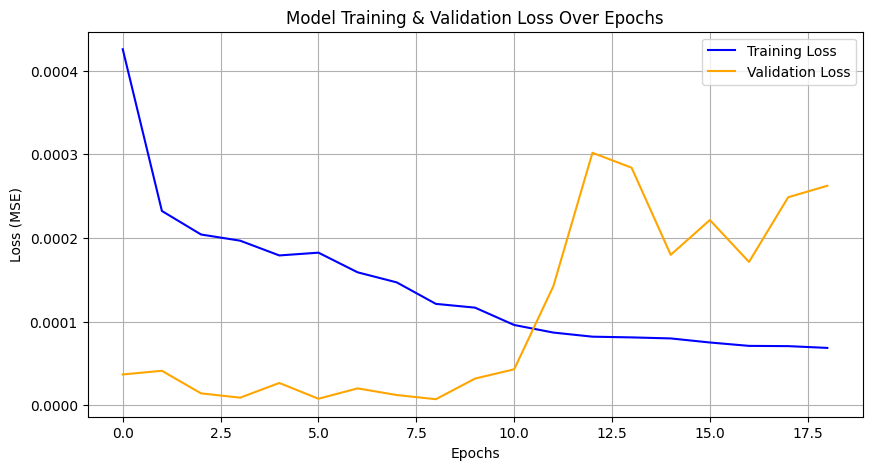

In [ ]:

# --- Visualize Training Performance ---
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title("Model Training & Validation Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

# --- Model Evaluation & Prediction ---

train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse scaling
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
Y_train_inv = scaler.inverse_transform([Y_train])
Y_test_inv = scaler.inverse_transform([Y_test])

# Calculate RMSE & R2
train_rmse = math.sqrt(mean_squared_error(Y_train_inv[0], train_predict[:,0]))
test_rmse = math.sqrt(mean_squared_error(Y_test_inv[0], test_predict[:,0]))
r2 = r2_score(Y_test_inv[0], test_predict[:,0])

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"R² Score: {r2:.4f}")


2604/2604 ━━━━━━━━━━━━━━━━━━━━ 48s 18ms/step
650/650 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step
Train RMSE: 800.3820
Test RMSE: 184.1964
R² Score: 0.9955


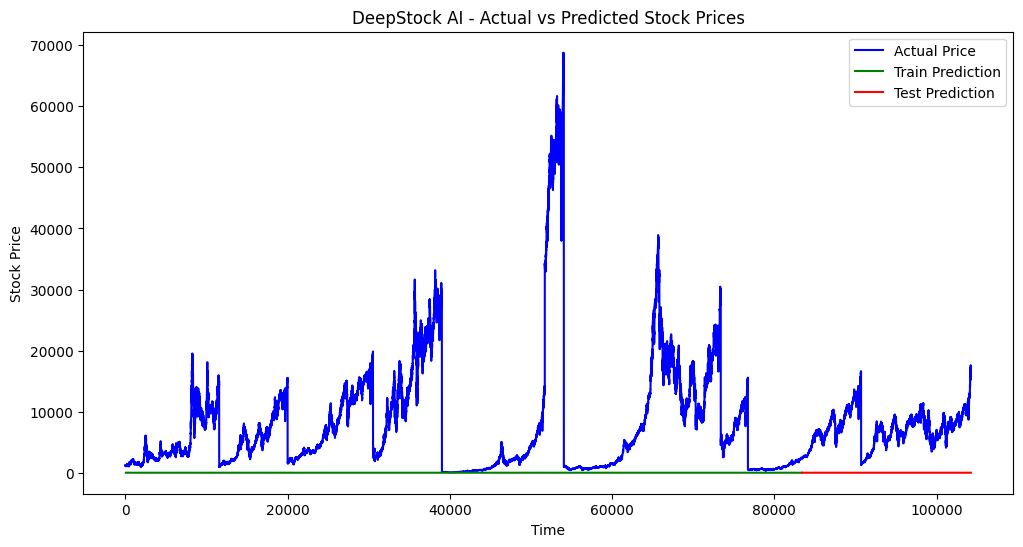

In [ ]:

# --- Visualization of Actual vs Predicted Prices ---

look_back = time_step

trainPredictPlot = np.empty_like(scaled_data)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = scaler.transform(train_predict)

testPredictPlot = np.empty_like(scaled_data)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(scaled_data)-1, :] = scaler.transform(test_predict)

# Plot
plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(scaled_data), label='Actual Price', color='blue')
plt.plot(trainPredictPlot, label='Train Prediction', color='green')
plt.plot(testPredictPlot, label='Test Prediction', color='red')
plt.title("DeepStock AI - Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()
